## Ticket Volume Forecast

**Step 1: Load dataset and prepare weekly aggregation**

In [ ]:
# Imporing necessary libraries
import pandas as pd
import numpy as np

# Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Defining the file path
file_path = '/content/drive/MyDrive/Customer Insights and Data Analytics Early Remote Internship/Cleaned_Freshdesk_Customer_Support_Tickets_Dataset_Filled.csv'

# Reading the CSV file
df = pd.read_csv(file_path)

# Ensuring Created Date is datetime
df['Created Date'] = pd.to_datetime(df['Created Date'])

# Setting Created Date as index (optional)
df.set_index('Created Date', inplace=True)

# Resample by week and count tickets
weekly_tickets = df['Ticket ID'].resample('W').count().reset_index()
weekly_tickets.rename(columns={'Ticket ID': 'Tickets'}, inplace=True)

# Displaying weekly ticket counts
print(weekly_tickets)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Created Date  Tickets
0   2026-01-04        2
1   2026-01-11       28


**Step 2: Option A — Weekly Average Forecast**

In [ ]:
# Calculate weekly average
average_tickets = weekly_tickets['Tickets'].mean()
print("Weekly Average Tickets:", round(average_tickets, 2))

# Forecast next 4 weeks using average
forecast_weeks = 4
forecast_avg = pd.DataFrame({
    'Week': range(1, forecast_weeks + 1),
    'Forecasted Tickets (Avg)': [round(average_tickets, 0)] * forecast_weeks
})

print(forecast_avg)


Weekly Average Tickets: 15.0
   Week  Forecasted Tickets (Avg)
0     1                      15.0
1     2                      15.0
2     3                      15.0
3     4                      15.0


**Step 3: Option B — Linear Trend Projection**

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Prepare data for linear regression
weekly_tickets['Week_Num'] = np.arange(len(weekly_tickets))  # 0,1,2,...
X = weekly_tickets[['Week_Num']]  # feature
y = weekly_tickets['Tickets']     # target

# Fit linear model
model = LinearRegression()
model.fit(X, y)

# Forecast next 4 weeks
future_weeks = np.arange(len(weekly_tickets), len(weekly_tickets) + forecast_weeks).reshape(-1,1)
forecast_linear = model.predict(future_weeks)

# Create dataframe
forecast_linear_df = pd.DataFrame({
    'Week': range(len(weekly_tickets)+1, len(weekly_tickets)+1+forecast_weeks),
    'Forecasted Tickets (Linear)': np.round(forecast_linear,0)
})

print(forecast_linear_df)


   Week  Forecasted Tickets (Linear)
0     3                         54.0
1     4                         80.0
2     5                        106.0
3     6                        132.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Step 4: Visualization - Combine Historical + Average + Linear Forecasts**

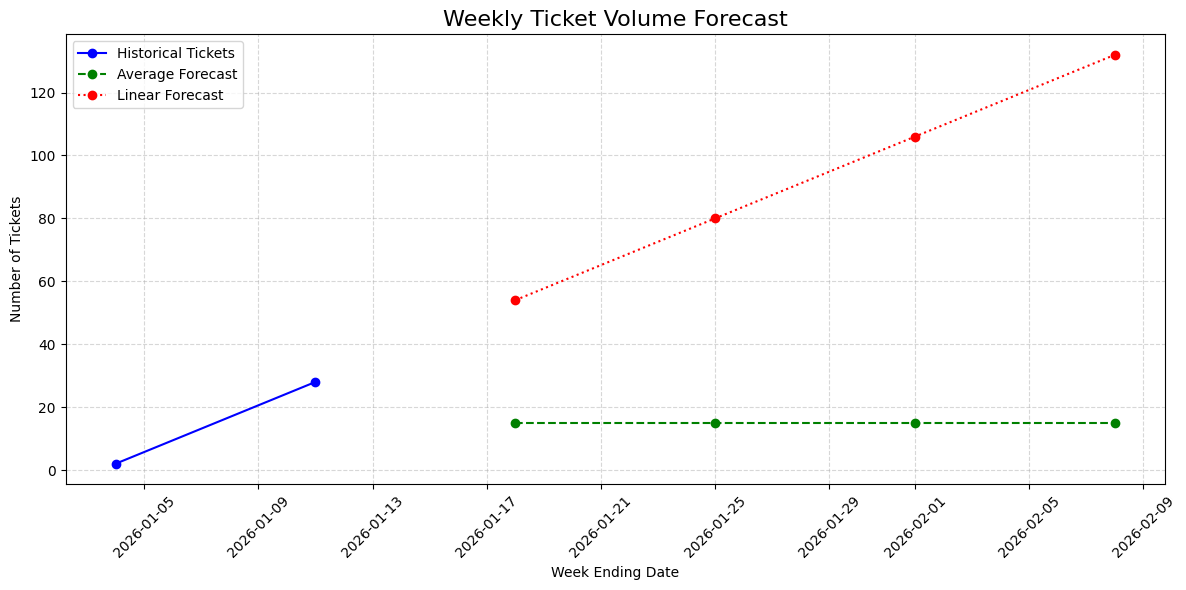

In [ ]:
import matplotlib.pyplot as plt

# Make a copy for plotting
combined_df_plot = combined_df.copy()

# Ensure 'Resolved Date' is datetime
combined_df_plot['Resolved Date'] = pd.to_datetime(combined_df_plot['Resolved Date'])

# Step 1: Historical Tickets
historical_mask = combined_df_plot['Historical_Tickets'].notna()

# Step 2: Average Forecast
avg_mask = combined_df_plot['Avg_Forecast'].notna()

# Step 3: Linear Forecast
linear_mask = combined_df_plot['Linear_Forecast'].notna()

# Step 4: Plot
plt.figure(figsize=(12,6))

# Historical Tickets
plt.plot(combined_df_plot['Resolved Date'][historical_mask],
         combined_df_plot['Historical_Tickets'][historical_mask],
         marker='o', linestyle='-', color='blue', label='Historical Tickets')

# Average Forecast
plt.plot(combined_df_plot['Resolved Date'][avg_mask],
         combined_df_plot['Avg_Forecast'][avg_mask],
         marker='o', linestyle='--', color='green', label='Average Forecast')

# Linear Forecast
plt.plot(combined_df_plot['Resolved Date'][linear_mask],
         combined_df_plot['Linear_Forecast'][linear_mask],
         marker='o', linestyle=':', color='red', label='Linear Forecast')

# Formatting
plt.title('Weekly Ticket Volume Forecast', fontsize=16)
plt.xlabel('Week Ending Date')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
